# Supermarket Sales Analytics — Python + Snowflake

This notebook connects to Snowflake, pulls the processed data from the analytics layer, and performs:
- Sales trend visualizations
- Category analysis
- Weekday and hourly patterns
- ABC classification chart
- Demand forecasting with Prophet
- Product clustering with K-Means

## 1. Setup & Connection

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv

# Load credentials from .env file
load_dotenv()

# Snowflake connection
conn = snowflake.connector.connect(
    account   = os.getenv('SNOWFLAKE_ACCOUNT'),
    user      = os.getenv('SNOWFLAKE_USER'),
    password  = os.getenv('SNOWFLAKE_PASSWORD'),
    database  = os.getenv('SNOWFLAKE_DATABASE'),
    warehouse = os.getenv('SNOWFLAKE_WAREHOUSE'),
    schema    = 'REPORTING'
)

print('Connected to Snowflake successfully!')

# Helper function to run queries
def query(sql):
    return pd.read_sql(sql, conn)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

Connected to Snowflake successfully!


## 2. Monthly Revenue Trend

/var/folders/wt/k04sj_gj2txbf9dld5w6kv840000gn/T/ipykernel_78463/3515545409.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


       month    revenue  volume_kg  transactions
0 2020-07-01  122761.26   13642.36         33559
1 2020-08-01  133932.03   15475.79         36577
2 2020-09-01  106561.18   12113.76         28148
3 2020-10-01  122721.65   15069.88         31876
4 2020-11-01   84608.69   14979.33         28034
month           datetime64[ns]
revenue                float64
volume_kg              float64
transactions             int64
dtype: object


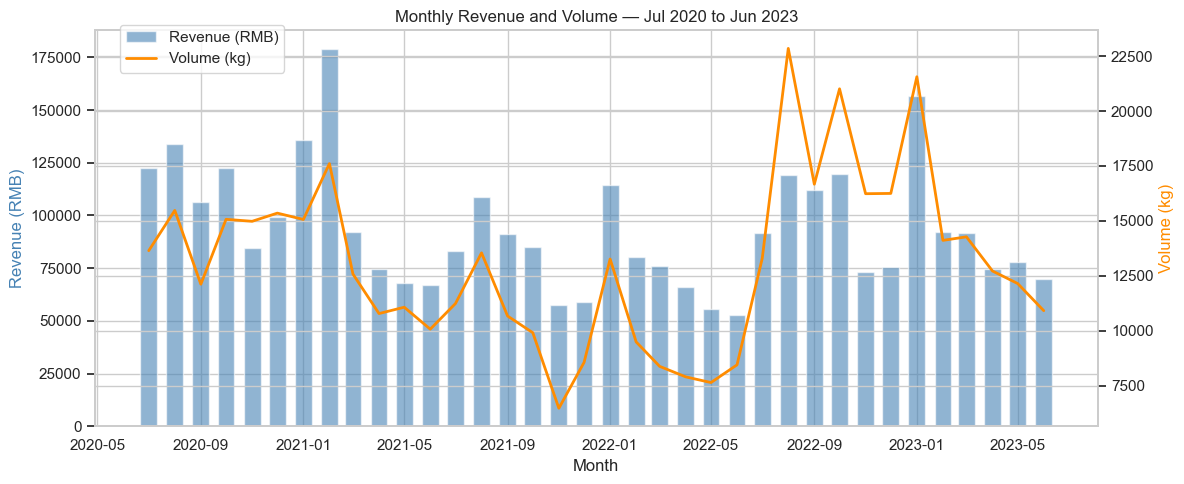

In [5]:
df_monthly = query("""
    SELECT
        DATE_TRUNC('MONTH', sale_date)        AS month,
        ROUND(SUM(gross_revenue_rmb), 2)      AS revenue,
        ROUND(SUM(quantity_sold_kg), 2)       AS volume_kg,
        COUNT(*)                              AS transactions
    FROM SUPERMARKET_DB.ANALYTICS.FACT_SALES
    WHERE txn_type = 'sale'
    GROUP BY month
    ORDER BY month
""")

# Fix column names and date format
df_monthly.columns = df_monthly.columns.str.lower()
df_monthly['month'] = pd.to_datetime(df_monthly['month'])

print(df_monthly.head())
print(df_monthly.dtypes)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.bar(df_monthly['month'], df_monthly['revenue'], width=20, alpha=0.6, color='steelblue', label='Revenue (RMB)')
ax2.plot(df_monthly['month'], df_monthly['volume_kg'], color='darkorange', linewidth=2, label='Volume (kg)')

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (RMB)', color='steelblue')
ax2.set_ylabel('Volume (kg)', color='darkorange')
plt.title('Monthly Revenue and Volume — Jul 2020 to Jun 2023')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

## 3. Revenue by Category

/var/folders/wt/k04sj_gj2txbf9dld5w6kv840000gn/T/ipykernel_78463/3515545409.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


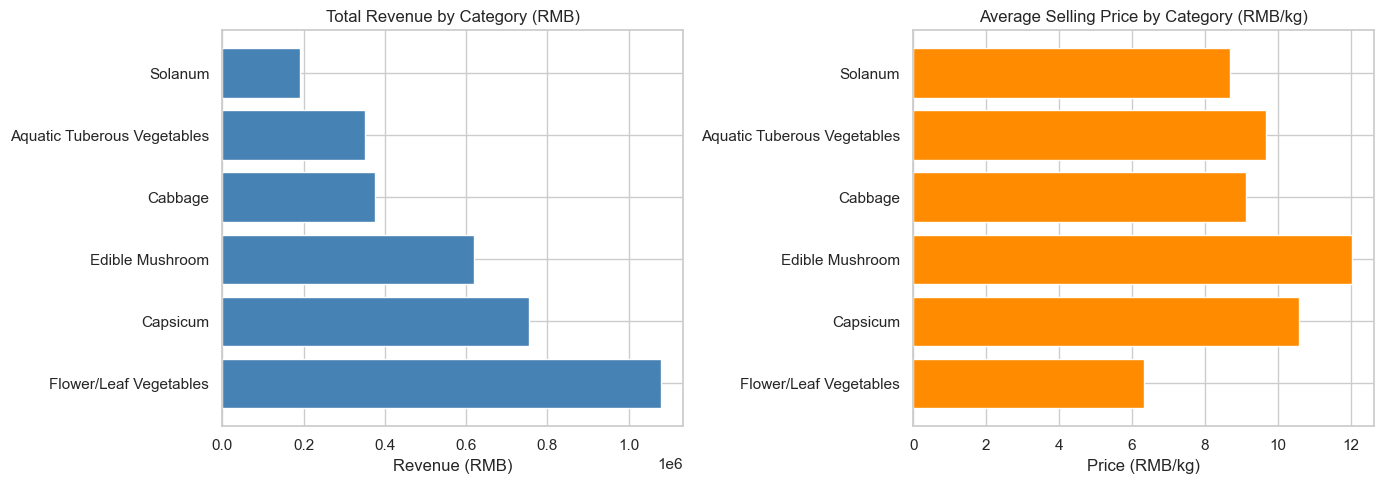

In [9]:
df_cat = query("""
    SELECT
        p.category_name,
        ROUND(SUM(f.gross_revenue_rmb), 2)    AS revenue,
        ROUND(AVG(f.unit_price_rmb_kg), 2)    AS avg_price,
        ROUND(SUM(f.quantity_sold_kg), 2)     AS volume_kg
    FROM SUPERMARKET_DB.ANALYTICS.FACT_SALES f
    JOIN SUPERMARKET_DB.ANALYTICS.DIM_PRODUCT p ON f.item_code = p.item_code
    WHERE f.txn_type = 'sale'
    GROUP BY p.category_name
    ORDER BY revenue DESC
""")
df_cat.columns = df_cat.columns.str.lower()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue bar chart
axes[0].barh(df_cat['category_name'], df_cat['revenue'], color='steelblue')
axes[0].set_title('Total Revenue by Category (RMB)')
axes[0].set_xlabel('Revenue (RMB)')

# Avg price bar chart
axes[1].barh(df_cat['category_name'], df_cat['avg_price'], color='darkorange')
axes[1].set_title('Average Selling Price by Category (RMB/kg)')
axes[1].set_xlabel('Price (RMB/kg)')

plt.tight_layout()
plt.show()

## 4. Sales Heatmap — Day of Week vs Hour

/var/folders/wt/k04sj_gj2txbf9dld5w6kv840000gn/T/ipykernel_78463/3515545409.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


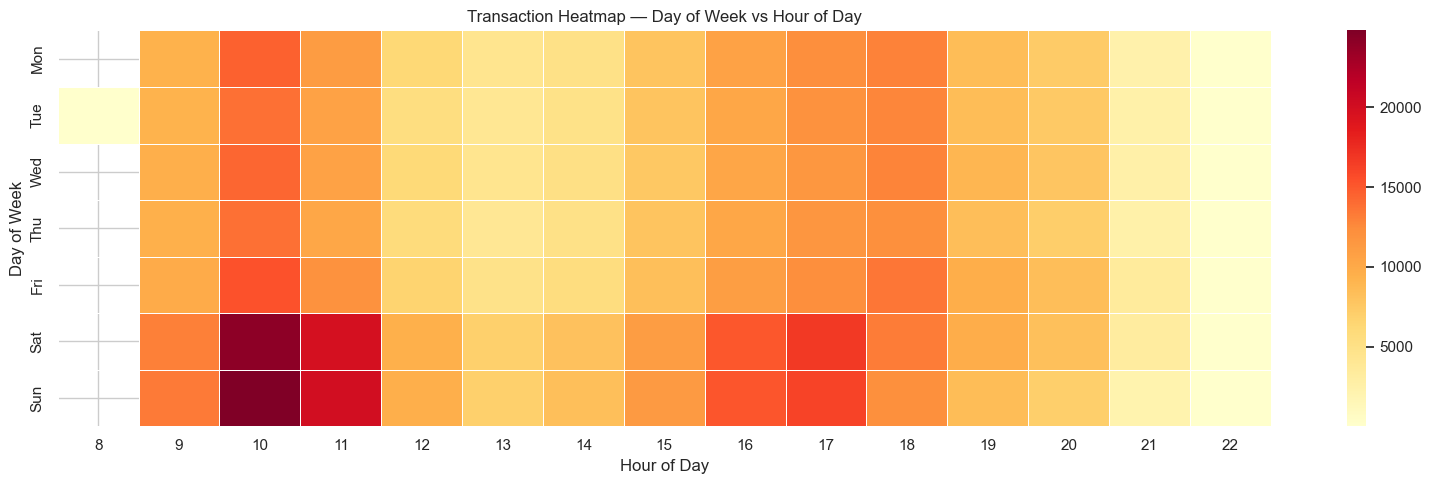

In [10]:
df_heatmap = query("""
    SELECT
        DAYNAME(sale_date)       AS day_name,
        DAYOFWEEK(sale_date)     AS day_num,
        sale_hour,
        COUNT(*)                 AS transactions
    FROM SUPERMARKET_DB.ANALYTICS.FACT_SALES
    WHERE txn_type = 'sale'
    GROUP BY day_name, day_num, sale_hour
    ORDER BY day_num, sale_hour
""")
df_heatmap.columns = df_heatmap.columns.str.lower()

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = df_heatmap.pivot_table(index='day_name', columns='sale_hour', values='transactions', aggfunc='sum')
pivot = pivot.reindex(day_order)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('Transaction Heatmap — Day of Week vs Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

## 5. ABC Classification Chart

/var/folders/wt/k04sj_gj2txbf9dld5w6kv840000gn/T/ipykernel_78463/3515545409.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


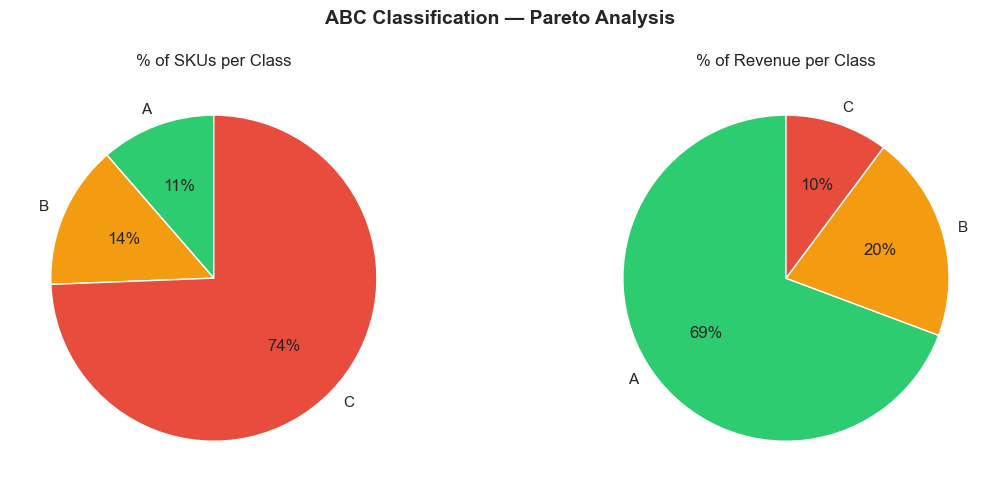

abc_class  products  revenue_pct
        A        28         69.3
        B        35         20.5
        C       183         10.2


In [15]:
df_abc = query("""
    SELECT abc_class, COUNT(*) AS products, ROUND(SUM(revenue_share_pct), 1) AS revenue_pct
    FROM SUPERMARKET_DB.REPORTING.VW_ABC_CLASSIFICATION
    GROUP BY abc_class
    ORDER BY abc_class
""")
df_abc.columns = df_abc.columns.str.lower()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].pie(df_abc['products'], labels=df_abc['abc_class'], autopct='%1.0f%%', colors=colors, startangle=90)
axes[0].set_title('% of SKUs per Class')

axes[1].pie(df_abc['revenue_pct'], labels=df_abc['abc_class'], autopct='%1.0f%%',
            colors=colors, startangle=90)
axes[1].set_title('% of Revenue per Class')

plt.suptitle('ABC Classification — Pareto Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_abc.to_string(index=False))

## 6. Product Clustering with K-Means

/var/folders/wt/k04sj_gj2txbf9dld5w6kv840000gn/T/ipykernel_78463/3515545409.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


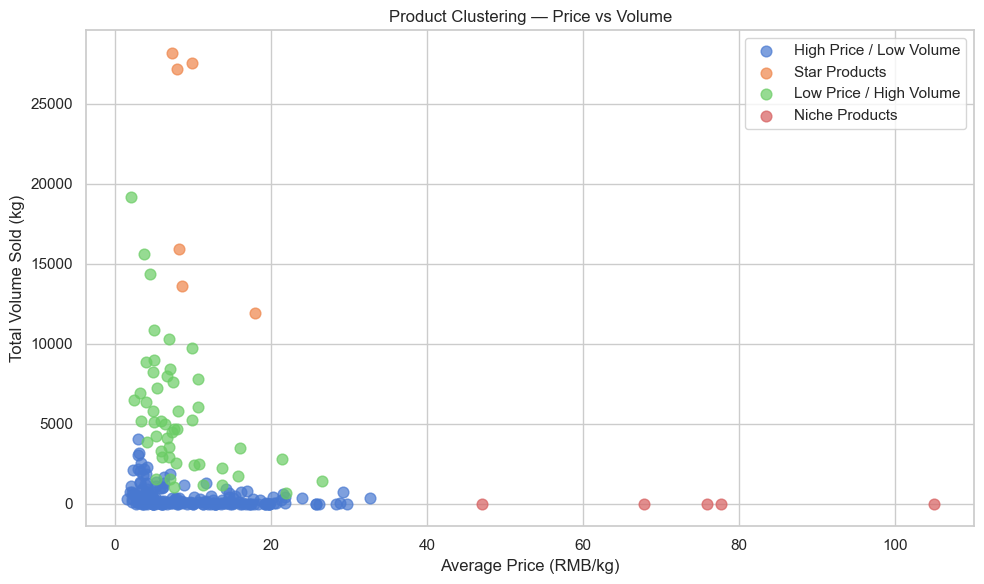

                         avg_price  total_volume  total_revenue  active_days
cluster_label                                                               
High Price / Low Volume      10.04        396.08        2479.14        83.02
Low Price / High Volume       8.20       5576.21       35996.67       519.73
Niche Products               74.65          2.65         213.05         8.40
Star Products                10.02      20726.27      191000.29       940.67


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Pull product-level features
df_products = query("""
    SELECT
        f.item_code,
        p.item_name,
        p.category_name,
        ROUND(AVG(f.unit_price_rmb_kg), 3)    AS avg_price,
        ROUND(SUM(f.quantity_sold_kg), 2)     AS total_volume,
        ROUND(SUM(f.gross_revenue_rmb), 2)    AS total_revenue,
        COUNT(DISTINCT f.sale_date)           AS active_days
    FROM SUPERMARKET_DB.ANALYTICS.FACT_SALES f
    JOIN SUPERMARKET_DB.ANALYTICS.DIM_PRODUCT p ON f.item_code = p.item_code
    WHERE f.txn_type = 'sale'
    GROUP BY f.item_code, p.item_name, p.category_name
""")
df_products.columns = df_products.columns.str.lower()

# Features for clustering
features = ['avg_price', 'total_volume', 'total_revenue', 'active_days']
X = df_products[features].fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_products['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster labels
cluster_labels = {0: 'Low Price / High Volume', 1: 'High Price / Low Volume',
                  2: 'Niche Products', 3: 'Star Products'}
df_products['cluster_label'] = df_products['cluster'].map(cluster_labels)

# Scatter plot
plt.figure(figsize=(10, 6))
for label in df_products['cluster_label'].unique():
    subset = df_products[df_products['cluster_label'] == label]
    plt.scatter(subset['avg_price'], subset['total_volume'], label=label, alpha=0.7, s=60)

plt.title('Product Clustering — Price vs Volume')
plt.xlabel('Average Price (RMB/kg)')
plt.ylabel('Total Volume Sold (kg)')
plt.legend()
plt.tight_layout()
plt.show()

# Cluster summary
print(df_products.groupby('cluster_label')[features].mean().round(2))

## 8. Close Connection

In [17]:
conn.close()
print('Connection closed.')

Connection closed.
